In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("Google_Stock_Price_Train.csv")

In [3]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [5]:
df['Close'] = df['Close'].str.replace(',','').astype(float)

In [6]:
df.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2012,325.25,332.83,324.97,663.59,"7,380,500"
1,1/4/2012,331.27,333.87,329.08,666.45,"5,749,400"
2,1/5/2012,329.83,330.75,326.89,657.21,"6,590,300"
3,1/6/2012,328.34,328.77,323.68,648.24,"5,405,900"
4,1/9/2012,322.04,322.29,309.46,620.76,"11,688,800"


In [7]:
train_set = df.iloc[: , 4:5].values

In [8]:
train_set

array([[663.59],
       [666.45],
       [657.21],
       ...,
       [785.05],
       [782.79],
       [771.82]])

In [9]:
from sklearn.preprocessing import MinMaxScaler
sc = MinMaxScaler()

In [10]:
train_set = sc.fit_transform(train_set)

In [12]:
train_set

array([[0.23757287],
       [0.24151427],
       [0.22878051],
       ...,
       [0.40495845],
       [0.40184391],
       [0.38672602]])

In [13]:
x_train = train_set[0:1257]
y_train = train_set[1:1258]

In [14]:
x_train = np.reshape(x_train , (1257,1,1))
x_train

array([[[0.23757287]],

       [[0.24151427]],

       [[0.22878051]],

       ...,

       [[0.41391618]],

       [[0.40495845]],

       [[0.40184391]]])

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout

In [17]:
model = Sequential(
    [
        LSTM(units = 50 , return_sequences = True, input_shape = (None, 1)),
        LSTM(units = 50 , return_sequences = True),
        Dropout(0.25),
        Dense(1 , activation='sigmoid')
    ]
)

In [18]:
model.compile(optimizer = 'adam' , loss = 'mean_squared_error')

In [20]:
history = model.fit(x_train , y_train , batch_size = 10 , epochs = 100)

Epoch 1/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 0.0631
Epoch 2/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0165
Epoch 3/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0019
Epoch 4/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016
Epoch 5/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017
Epoch 6/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 7/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 8/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0017
Epoch 9/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0017
Epoch 10/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016
Epoch 11/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0017
Epoch 12/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 0.0016
Epoch 13/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016
Epoch 14/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0016
Epoch 15/100
126/126 ━━━━━━━━━━━━━━━━━━━━ 

In [21]:
test_set = pd.read_csv("Google_Stock_Price_Test.csv")

In [22]:
test_set.head()

,Date,Open,High,Low,Close,Volume
0,1/3/2017,778.81,789.63,775.80,786.14,"1,657,300"
1,1/4/2017,788.36,791.34,783.16,786.90,"1,073,000"
2,1/5/2017,786.08,794.48,785.02,794.02,"1,335,200"
3,1/6/2017,795.26,807.90,792.20,806.15,"1,640,200"
4,1/9/2017,806.40,809.97,802.83,806.65,"1,272,400"


In [23]:
test_set = test_set.iloc[:, 4:5].values
test_set

array([[786.14],
       [786.9 ],
       [794.02],
       [806.15],
       [806.65],
       [804.79],
       [807.91],
       [806.36],
       [807.88],
       [804.61],
       [806.07],
       [802.17],
       [805.02],
       [819.31],
       [823.87],
       [835.67],
       [832.15],
       [823.31],
       [802.32],
       [796.79]])

In [24]:
inputs = sc.transform(test_set)
inputs

array([[0.40646059],
       [0.40750796],
       [0.41732012],
       [0.43403663],
       [0.43472569],
       [0.4321624 ],
       [0.43646211],
       [0.43432603],
       [0.43642077],
       [0.43191434],
       [0.43392638],
       [0.42855174],
       [0.43247936],
       [0.45217259],
       [0.45845679],
       [0.47471852],
       [0.46986756],
       [0.45768505],
       [0.42875846],
       [0.42113749]])

In [25]:
inputs = np.reshape(inputs, (20,1,1))
inputs

array([[[0.40646059]],

       [[0.40750796]],

       [[0.41732012]],

       [[0.43403663]],

       [[0.43472569]],

       [[0.4321624 ]],

       [[0.43646211]],

       [[0.43432603]],

       [[0.43642077]],

       [[0.43191434]],

       [[0.43392638]],

       [[0.42855174]],

       [[0.43247936]],

       [[0.45217259]],

       [[0.45845679]],

       [[0.47471852]],

       [[0.46986756]],

       [[0.45768505]],

       [[0.42875846]],

       [[0.42113749]]])

In [27]:
predict_value = model.predict(inputs)
predict_value

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 468ms/step


array([[[0.4064354 ]],

       [[0.40740243]],

       [[0.41647005]],

       [[0.4319745 ]],

       [[0.43261576]],

       [[0.4302313 ]],

       [[0.43423262]],

       [[0.4322438 ]],

       [[0.43419412]],

       [[0.4300007 ]],

       [[0.43187195]],

       [[0.42687696]],

       [[0.43052602]],

       [[0.44892895]],

       [[0.45484725]],

       [[0.47028992]],

       [[0.46566254]],

       [[0.45411906]],

       [[0.4270689 ]],

       [[0.42000306]]], dtype=float32)

In [28]:
predict_value = np.reshape(predict_value , (20,1))

In [29]:
predict_value

array([[0.4064354 ],
       [0.40740243],
       [0.41647005],
       [0.4319745 ],
       [0.43261576],
       [0.4302313 ],
       [0.43423262],
       [0.4322438 ],
       [0.43419412],
       [0.4300007 ],
       [0.43187195],
       [0.42687696],
       [0.43052602],
       [0.44892895],
       [0.45484725],
       [0.47028992],
       [0.46566254],
       [0.45411906],
       [0.4270689 ],
       [0.42000306]], dtype=float32)

In [31]:
test_pred = sc.inverse_transform(predict_value) # inverse_transform is doing again normal data

In [32]:
test_pred

array([[786.1217 ],
       [786.82336],
       [793.40314],
       [804.6537 ],
       [805.11896],
       [803.38873],
       [806.2922 ],
       [804.84906],
       [806.2642 ],
       [803.2214 ],
       [804.5793 ],
       [800.9548 ],
       [803.6026 ],
       [816.9563 ],
       [821.2508 ],
       [832.4565 ],
       [829.09875],
       [820.7224 ],
       [801.09406],
       [795.9668 ]], dtype=float32)

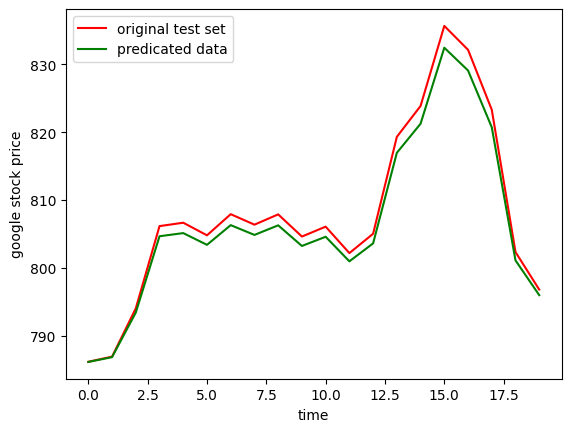

In [33]:
plt.plot(test_set, color = 'red' , label= 'original test set')
plt.plot(test_pred , color ='green' , label = 'predicated data')
plt.xlabel("time")
plt.ylabel("google stock price")
plt.legend()
plt.show()

In [34]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test_set, test_pred))
print("RMSE:", rmse)

RMSE: 1.7747370810655818


In [35]:
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(test_set, test_pred)
print("MAE:", mae)

MAE: 1.5635667724609221


In [36]:
from sklearn.metrics import mean_absolute_percentage_error

mape = mean_absolute_percentage_error(test_set, test_pred)
print("MAPE:", mape * 100, "%")

MAPE: 0.19194047971099437 %


In [38]:
model.save("google_stock_lstm.keras")